# Correspondence Analysis: Age Groups and Product Categories

This Notebook uses Correspondence Analysis (CA) to visualize relationships between customer age groups and preferred product categories.

# 対応分析：年代と商品カテゴリの関係を可視化する

このNotebookでは、顧客の年代と選好する商品カテゴリの関係を、対応分析（Correspondence Analysis: CA）で可視化します。

## 1. Learning Objectives / 学習目標
- Understand correspondence analysis for contingency tables
- Calculate row and column profiles
- Examine expected frequencies and standardized residuals
- Understand chi-square geometry and inertia
- Perform correspondence analysis using SVD
- Interpret row and column coordinates
- Read a correspondence map

- クロス集計表に対する対応分析を理解する
- 行プロファイル・列プロファイルを理解する
- 期待度数と標準化残差を確認する
- カイ二乗距離と慣性を理解する
- SVDを使って対応分析を実行する
- 行・列カテゴリの座標を解釈する
- 対応分析マップを読む

## 2. Use Case / ユースケース

A retail company wants to understand how product preferences differ by customer age group.

The data is a contingency table of age groups and preferred product categories.

ある小売企業では、年代によって好まれる商品カテゴリがどのように異なるかを把握したいと考えています。

今回のデータは、年代 × 商品カテゴリのクロス集計表です。

## 3. What Is Correspondence Analysis? / 対応分析とは

Correspondence Analysis is a multivariate method designed for contingency tables.

It represents row categories and column categories in a low-dimensional space using chi-square geometry.

対応分析は、クロス集計表の構造を低次元空間に配置して可視化する多変量解析手法です。

主成分分析に似た性質がありますが、通常のユークリッド距離ではなくカイ二乗距離に基づきます。

## 4. Import Libraries / ライブラリの読み込み

In [17]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

pd.set_option("display.max_columns", None)

## 5. Load the Contingency Table / クロス集計表の読み込み

In [18]:
paths=[
    Path("../data/age_product_contingency.csv"),
    Path("08_correspondence_analysis/data/age_product_contingency.csv"),
    Path("data/age_product_contingency.csv")
]
data_path=next((p for p in paths if p.exists()),None)
if data_path is None:
    raise FileNotFoundError("age_product_contingency.csv was not found.")

raw_df=pd.read_csv(data_path)
table=raw_df.set_index("age_group")
table

,Electronics,Fashion,Home_Living,Beauty,Sports
age_group,,,,,
18-24,78,96,24,42,61
25-34,92,88,51,57,68
35-44,74,58,83,49,62
45-54,52,39,101,44,48
55-64,34,27,94,55,33
65+,21,18,87,63,19


## 6. Visualize the Contingency Table / クロス集計表を可視化する

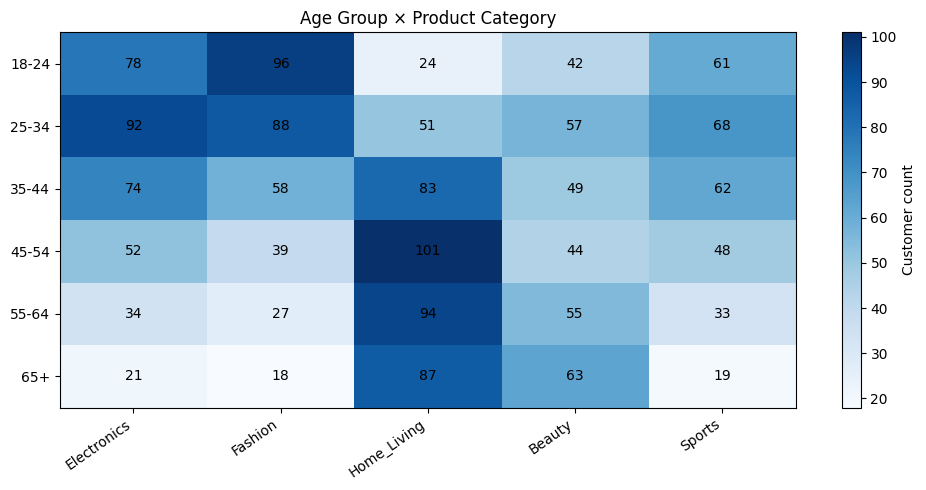

In [19]:
fig,ax=plt.subplots(figsize=(10,5))
image=ax.imshow(table.values,aspect="auto",cmap="Blues")
ax.set_xticks(range(table.shape[1]),labels=table.columns,rotation=35,ha="right")
ax.set_yticks(range(table.shape[0]),labels=table.index)
for i in range(table.shape[0]):
    for j in range(table.shape[1]):
        ax.text(j,i,str(table.iloc[i,j]),ha="center",va="center")
fig.colorbar(image,ax=ax,label="Customer count")
ax.set_title("Age Group × Product Category")
plt.tight_layout(); plt.show()

## 7. Row and Column Totals / 行合計と列合計

In [20]:
row_totals=table.sum(axis=1)
column_totals=table.sum(axis=0)
print("Row totals"); display(row_totals.to_frame("total"))
print("Column totals"); display(column_totals.to_frame("total"))

Row totals


,total
age_group,
18-24,301
25-34,356
35-44,326
45-54,284
55-64,243
65+,208


Column totals


,total
Electronics,351
Fashion,326
Home_Living,440
Beauty,310
Sports,291


## 8. Row Profiles / 行プロファイル

A row profile shows the product-category composition within each age group. Each row sums to 1.

行プロファイルは、各年代の中で各商品カテゴリが占める割合を表します。各行の合計は1です。

In [21]:
row_profiles=table.div(table.sum(axis=1),axis=0)
row_profiles.round(3)

,Electronics,Fashion,Home_Living,Beauty,Sports
age_group,,,,,
18-24,0.259,0.319,0.080,0.140,0.203
25-34,0.258,0.247,0.143,0.160,0.191
35-44,0.227,0.178,0.255,0.150,0.190
45-54,0.183,0.137,0.356,0.155,0.169
55-64,0.140,0.111,0.387,0.226,0.136
65+,0.101,0.087,0.418,0.303,0.091


## 9. Column Profiles / 列プロファイル

A column profile shows the age composition within each product category. Each column sums to 1.

列プロファイルは、各商品カテゴリの中で年代が占める割合を表します。各列の合計は1です。

In [22]:
column_profiles=table.div(table.sum(axis=0),axis=1)
column_profiles.round(3)

,Electronics,Fashion,Home_Living,Beauty,Sports
age_group,,,,,
18-24,0.222,0.294,0.055,0.135,0.210
25-34,0.262,0.270,0.116,0.184,0.234
35-44,0.211,0.178,0.189,0.158,0.213
45-54,0.148,0.120,0.230,0.142,0.165
55-64,0.097,0.083,0.214,0.177,0.113
65+,0.060,0.055,0.198,0.203,0.065


## 10. Test of Independence / 独立性の検定

In [23]:
chi2_stat,p_value,dof,expected=chi2_contingency(table)
print(f"Chi-square statistic: {chi2_stat:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.6f}")

Chi-square statistic: 225.486
Degrees of freedom: 20
P-value: 0.000000


A small p-value suggests that age group and product category are not independent.

ただし、カイ二乗検定だけでは、どのカテゴリ同士が特に関連しているかまでは分かりません。対応分析でその構造を可視化します。

## 11. Expected Frequencies and Residuals / 期待度数と残差

In [24]:
expected_df=pd.DataFrame(expected,index=table.index,columns=table.columns)
expected_df.round(1)

,Electronics,Fashion,Home_Living,Beauty,Sports
age_group,,,,,
18-24,61.5,57.1,77.1,54.3,51.0
25-34,72.7,67.6,91.2,64.2,60.3
35-44,66.6,61.9,83.5,58.8,55.2
45-54,58.0,53.9,72.7,51.2,48.1
55-64,49.6,46.1,62.2,43.8,41.2
65+,42.5,39.5,53.3,37.5,35.2


In [25]:
standardized_residuals=(table-expected_df)/np.sqrt(expected_df)
standardized_residuals.round(2)

,Electronics,Fashion,Home_Living,Beauty,Sports
age_group,,,,,
18-24,2.10,5.15,-6.05,-1.67,1.40
25-34,2.26,2.49,-4.21,-0.90,0.99
35-44,0.91,-0.49,-0.05,-1.28,0.91
45-54,-0.79,-2.03,3.31,-1.01,-0.02
55-64,-2.22,-2.81,4.03,1.68,-1.27
65+,-3.30,-3.42,4.62,4.16,-2.73


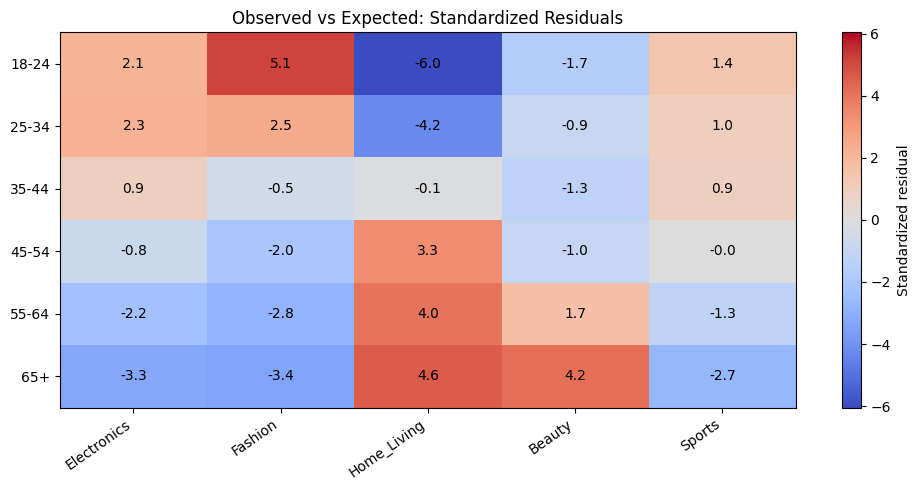

In [26]:
fig,ax=plt.subplots(figsize=(10,5))
limit=np.abs(standardized_residuals.values).max()
image=ax.imshow(standardized_residuals.values,aspect="auto",cmap="coolwarm",vmin=-limit,vmax=limit)
ax.set_xticks(range(table.shape[1]),labels=table.columns,rotation=35,ha="right")
ax.set_yticks(range(table.shape[0]),labels=table.index)
for i in range(table.shape[0]):
    for j in range(table.shape[1]):
        ax.text(j,i,f"{standardized_residuals.iloc[i,j]:.1f}",ha="center",va="center")
fig.colorbar(image,ax=ax,label="Standardized residual")
ax.set_title("Observed vs Expected: Standardized Residuals")
plt.tight_layout(); plt.show()

## 12. Correspondence Analysis Mathematics / 対応分析の計算

Let `N` be the contingency table and `n` its grand total.

`P = N / n`

The standardized correspondence matrix is:

`S = Dr^(-1/2) (P - r cᵀ) Dc^(-1/2)`

Correspondence Analysis applies Singular Value Decomposition (SVD) to this matrix.

クロス集計表を相対度数行列へ変換し、独立モデルとの差を行・列質量で標準化した行列にSVDを適用します。

## 13. Perform Correspondence Analysis / 対応分析を実行する

In [27]:
N=table.to_numpy(dtype=float)
grand_total=N.sum()
P=N/grand_total
row_masses=P.sum(axis=1)
column_masses=P.sum(axis=0)
expected_relative=np.outer(row_masses,column_masses)
S=(P-expected_relative)/np.sqrt(np.outer(row_masses,column_masses))

U,singular_values,VT=np.linalg.svd(S,full_matrices=False)
eigenvalues=singular_values**2

print("Singular values:",np.round(singular_values,4))
print("Eigenvalues:",np.round(eigenvalues,4))

Singular values: [0.3477 0.0968 0.0314 0.0058 0.    ]
Eigenvalues: [0.1209 0.0094 0.001  0.     0.    ]


## 14. Inertia / 慣性

Inertia in Correspondence Analysis is analogous to variance in PCA.

`Total inertia = Chi-square / Grand total`

対応分析の慣性は、PCAにおける分散に近い役割を持ちます。総慣性はカイ二乗統計量を総度数で割った値と一致します。

In [28]:
total_inertia=eigenvalues.sum()
print(f"Total inertia from SVD: {total_inertia:.6f}")
print(f"Chi-square / total count: {chi2_stat/grand_total:.6f}")

explained=eigenvalues/total_inertia
inertia_df=pd.DataFrame({
    "dimension":[f"Dim{i+1}" for i in range(len(eigenvalues))],
    "eigenvalue":eigenvalues,
    "explained_inertia":explained,
    "cumulative_inertia":np.cumsum(explained)
})
inertia_df.round(4)

Total inertia from SVD: 0.131249
Chi-square / total count: 0.131249


,dimension,eigenvalue,explained_inertia,cumulative_inertia
0,Dim1,0.1209,0.9209,0.9209
1,Dim2,0.0094,0.0713,0.9922
2,Dim3,0.0010,0.0075,0.9997
3,Dim4,0.0000,0.0003,1.0000
4,Dim5,0.0000,0.0000,1.0000


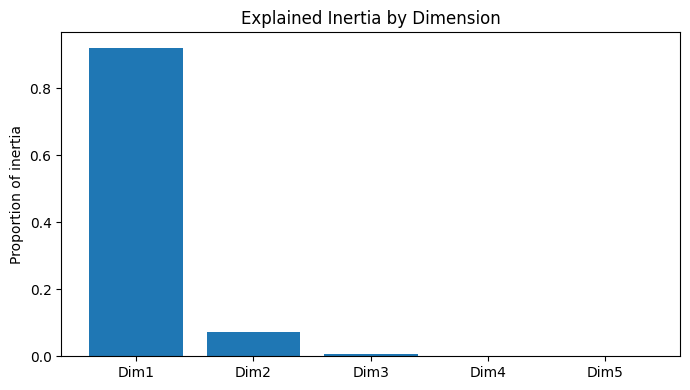

In [29]:
plt.figure(figsize=(7,4))
plt.bar(inertia_df["dimension"],inertia_df["explained_inertia"])
plt.ylabel("Proportion of inertia")
plt.title("Explained Inertia by Dimension")
plt.tight_layout(); plt.show()

## 15. Calculate Row and Column Coordinates / 行・列カテゴリの座標

In [30]:
row_coordinates=(U/np.sqrt(row_masses[:,None]))*singular_values
column_coordinates=(VT.T/np.sqrt(column_masses[:,None]))*singular_values

row_coord_df=pd.DataFrame(row_coordinates[:,:2],index=table.index,columns=["Dim1","Dim2"])
column_coord_df=pd.DataFrame(column_coordinates[:,:2],index=table.columns,columns=["Dim1","Dim2"])

print("Row coordinates"); display(row_coord_df.round(3))
print("Column coordinates"); display(column_coord_df.round(3))

Row coordinates


,Dim1,Dim2
age_group,,
18-24,-0.482,0.072
25-34,-0.290,0.029
35-44,-0.037,-0.093
45-54,0.198,-0.137
55-64,0.371,0.007
65+,0.549,0.170


Column coordinates


,Dim1,Dim2
Electronics,-0.267,-0.055
Fashion,-0.409,0.064
Home_Living,0.478,-0.067
Beauty,0.233,0.174
Sports,-0.190,-0.088


## 16. Correspondence Map / 対応分析マップ

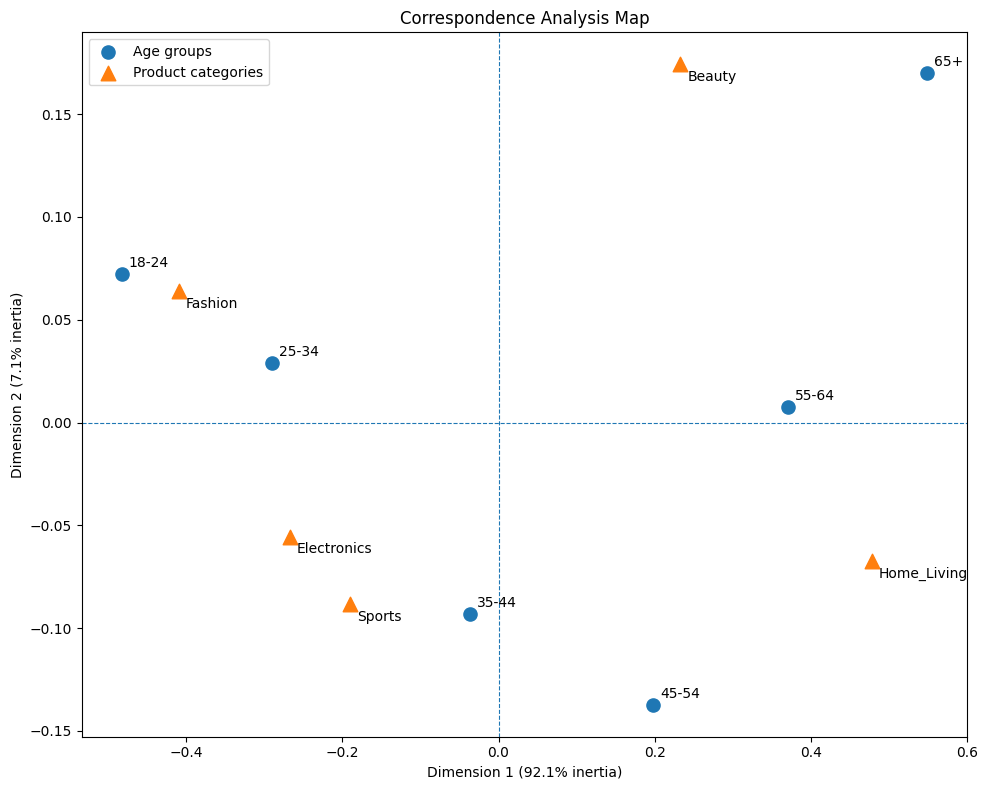

In [31]:
plt.figure(figsize=(10,8))
plt.scatter(row_coord_df["Dim1"],row_coord_df["Dim2"],marker="o",s=90,label="Age groups")
plt.scatter(column_coord_df["Dim1"],column_coord_df["Dim2"],marker="^",s=110,label="Product categories")

for label,row in row_coord_df.iterrows():
    plt.annotate(label,(row["Dim1"],row["Dim2"]),xytext=(5,5),textcoords="offset points")
for label,row in column_coord_df.iterrows():
    plt.annotate(label,(row["Dim1"],row["Dim2"]),xytext=(5,-12),textcoords="offset points")

plt.axhline(0,linewidth=.8,linestyle="--")
plt.axvline(0,linewidth=.8,linestyle="--")
plt.xlabel(f"Dimension 1 ({explained[0]*100:.1f}% inertia)")
plt.ylabel(f"Dimension 2 ({explained[1]*100:.1f}% inertia)")
plt.title("Correspondence Analysis Map")
plt.legend()
plt.tight_layout(); plt.show()

## 17. How to Read the Map / マップの読み方

- Row categories close to each other have similar column profiles.
- Column categories close to each other have similar row profiles.
- Row and column categories pointing in a similar direction from the origin may indicate association.
- Do not interpret row-to-column Euclidean distance too literally.

- 近くにある年代同士は商品カテゴリ構成が似ています。
- 近くにある商品カテゴリ同士は年代構成が似ています。
- 原点から見て同じ方向にある行カテゴリと列カテゴリには関連が示唆されます。
- 行点と列点の直接距離を、そのまま関係の強さと解釈しないことが重要です。

## 18. Contribution of Categories / カテゴリの寄与

In [32]:
row_contributions=row_masses[:,None]*row_coordinates[:,:2]**2/eigenvalues[:2]
column_contributions=column_masses[:,None]*column_coordinates[:,:2]**2/eigenvalues[:2]

row_contrib_df=pd.DataFrame(row_contributions,index=table.index,columns=["Dim1","Dim2"])
column_contrib_df=pd.DataFrame(column_contributions,index=table.columns,columns=["Dim1","Dim2"])

print("Row contributions"); display(row_contrib_df.round(3))
print("Column contributions"); display(column_contrib_df.round(3))

Row contributions


,Dim1,Dim2
age_group,,
18-24,0.337,0.098
25-34,0.144,0.019
35-44,0.002,0.175
45-54,0.054,0.333
55-64,0.161,0.001
65+,0.302,0.374


Column contributions


,Dim1,Dim2
Electronics,0.121,0.067
Fashion,0.263,0.083
Home_Living,0.485,0.124
Beauty,0.081,0.585
Sports,0.051,0.142


## 19. Interpretation / 分析結果の解釈

For this educational dataset, the intended structure is:

- younger groups are relatively associated with Fashion, Electronics, and Sports
- middle-aged groups shift toward Home & Living
- older groups show stronger relative association with Home & Living and Beauty

Interpret the map together with row profiles, column profiles, residuals, coordinates, and contributions.

今回の学習用データでは、おおむね次の構造を持たせています。

- 若年層はFashion、Electronics、Sportsとの関連が比較的強い
- 中年層ではHome & Living側へ移る
- 高年齢層ではHome & LivingやBeautyとの相対的関連が強まる

マップだけでなく、行・列プロファイル、残差、座標、寄与度と合わせて解釈します。

## 20. Correspondence Analysis and PCA / 対応分析と主成分分析

| PCA | Correspondence Analysis |
|---|---|
| Continuous numerical variables | Contingency tables / count data |
| Euclidean geometry | Chi-square geometry |
| Variance | Inertia |
| Observation-variable structure | Row-column category structure |

| 主成分分析 | 対応分析 |
|---|---|
| 連続数値変数 | クロス集計・度数データ |
| ユークリッド距離 | カイ二乗距離 |
| 分散 | 慣性 |
| 観測・変数の構造 | 行・列カテゴリの構造 |

## 21. Assumptions and Limitations / 前提条件と限界

- Input should be non-negative count/frequency data.
- Sparse tables can produce unstable maps.
- Rare categories may appear far from the origin.
- Association does not imply causation.
- A 2D map may omit later-dimensional information.
- Row-to-column distances should not be interpreted as ordinary Euclidean distances.
- This dataset is simulated for education.

- 入力は非負の度数・頻度データであること。
- スパースな表では結果が不安定になる可能性がある。
- 少数カテゴリは原点から大きく離れることがある。
- 関連は因果を意味しない。
- 2次元表示では後続次元の情報が失われることがある。
- 行点と列点の距離を通常のユークリッド距離として解釈しない。
- 今回は学習用シミュレーションデータである。

## 22. Conclusion / まとめ

This Notebook applied Correspondence Analysis to an Age Group × Product Category contingency table.

The workflow was:

1. Read the contingency table
2. Calculate row and column profiles
3. Perform a chi-square test
4. Examine expected frequencies and residuals
5. Construct the standardized correspondence matrix
6. Apply SVD
7. Calculate inertia
8. Calculate row and column coordinates
9. Create a correspondence map
10. Interpret associations and contributions

対応分析は、2つのカテゴリ変数の関係をクロス集計表から探索・可視化したい場合に有効な手法です。